# SAGE baseline experiments - overview

Everything the co-author guide asked for, in one place: what the baselines
score, how they compare to SAGE's locked 78.4%, and which conclusions survive
a leakage-controlled split.

**Read this first, then the per-task notebooks:**

| Notebook | Guide task |
|---|---|
| `01_task1_same_feature_baselines.ipynb` | Task 1 - k-NN / SVM on the same 13 features |
| `02_task2_pointnet_raw_points.ipynb` | Task 2 - PointNet on raw point clouds |
| `03_task3_sample_efficiency.ipynb` | Task 3 - accuracy vs examples per category |
| `04_task4_robustness.ipynb` | Task 4 - downsampling and sensor noise |
| `05_task5_statistics.ipynb` | Task 5 - confidence intervals and significance |

Nothing here retrains anything. Every number is read from the CSVs that
`run_all.py` produced, so a figure in a notebook can never disagree with the
script that generated it.

In [1]:
import sys
from pathlib import Path

# Use the project's src/ modules rather than re-implementing anything here.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import results_io as rio
import viz_style as vs

vs.apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

print("Reading results from:", rio.RESULTS_DIR)


Reading results from: C:\Users\suraj\Desktop\ICRA\sage_baseline_experiments\results


## The one caveat that changes how you read every number

`export_baseline_data.py` iterates over YCB-Video **frames** and emits one row
per object *per frame*. The 1109 rows are therefore repeated observations of a
much smaller set of physical objects, seen across the frames of ~12 validation
videos.

A plain `StratifiedKFold` splits those rows independently, so near-identical
views of one object land in **both** the training and the test fold, and a
classifier can retrieve a memorised neighbour instead of generalising. SAGE's
own 78.4% used a *video-level* split, so a random-split baseline is not
comparable to it.

Every task therefore reports **three** regimes:

| Regime | Splitter | Objects whole? | Folds stratified? |
|---|---|---|---|
| `random` | `StratifiedKFold` | no - leaks | yes |
| `grouped` | `StratifiedGroupKFold` | yes | yes |
| `groupkfold` | `GroupKFold` | yes | no |

`groupkfold` is the closest analogue of how SAGE's own 78.4% was
measured. Stratifying uses the label distribution to build the folds, and
a real video-level split cannot do that - you hold out whole videos and
accept whatever class mix falls out. So **quote `groupkfold`**; `grouped`
is the lower-variance companion estimate, and `random` is kept only to
show the size of the leak.

In [2]:
# How many physical objects are actually in the 1109 rows?
from data_utils import load_pointcloud_data, compute_object_groups

clouds, labels = load_pointcloud_data()
groups = compute_object_groups(clouds, distance_threshold=0.003)

object_counts = (
    pd.DataFrame({"label": labels, "group": groups})
    .groupby("label")
    .agg(distinct_objects=("group", "nunique"), rows=("group", "size"))
    .reindex(rio.CLASSES)
)

object_counts.loc["TOTAL"] = [len(np.unique(groups)), len(labels)]
object_counts

,distinct_objects,rows
label,,
box,93,475
can,55,355
mug,22,89
bottle,58,146
bowl,26,44
TOTAL,201,1109


201 distinct objects behind 1109 rows. Bowl is the extreme case: 44 rows, but
only 26 genuinely different bowls.

### What the two group-aware splitters actually produce

`StratifiedGroupKFold` keeps the class mix even across folds. `GroupKFold`
balances fold *size* only, so the class mix wanders - which is exactly what
happens when you hold out whole videos.

In [3]:
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

labels = np.asarray(labels)
rows = []

for name, splitter in [
    ("StratifiedGroupKFold", StratifiedGroupKFold(5, shuffle=True, random_state=42)),
    ("GroupKFold", GroupKFold(5, shuffle=True, random_state=42)),
]:
    for fold, (train_idx, test_idx) in enumerate(
        splitter.split(np.zeros(len(labels)), labels, groups=groups), start=1
    ):
        # The whole point of a group-aware split: check it actually holds.
        assert not (set(groups[train_idx]) & set(groups[test_idx])), "group overlap!"
        row = {"splitter": name, "fold": fold, "test_size": len(test_idx)}
        row.update({c: int((labels[test_idx] == c).sum()) for c in rio.CLASSES})
        rows.append(row)

fold_composition = pd.DataFrame(rows)
print("No group appears in both train and test, in any fold, for either splitter.")
fold_composition

No group appears in both train and test, in any fold, for either splitter.


,splitter,fold,test_size,box,can,mug,bottle,bowl
0,StratifiedGroupKFold,1,222,95,71,17,30,9
1,StratifiedGroupKFold,2,222,95,71,18,29,9
2,StratifiedGroupKFold,3,222,95,71,18,29,9
3,StratifiedGroupKFold,4,221,95,71,17,29,9
4,StratifiedGroupKFold,5,222,95,71,19,29,8
5,GroupKFold,1,214,108,37,26,37,6
6,GroupKFold,2,288,101,124,23,34,6
7,GroupKFold,3,181,86,60,11,13,11
8,GroupKFold,4,230,89,67,18,45,11
9,GroupKFold,5,196,91,67,11,17,10


In [4]:
# How uneven do the folds get?
spread = (
    fold_composition
    .groupby("splitter")[["test_size"] + rio.CLASSES]
    .agg(lambda column: f"{column.min()}-{column.max()}")
)
spread

,test_size,box,can,mug,bottle,bowl
splitter,,,,,,
GroupKFold,181-288,86-108,37-124,11-26,13-45,6-11
StratifiedGroupKFold,221-222,95-95,71-71,17-19,29-30,8-9


`GroupKFold`'s folds range 181-288 instances and its `can` count swings
37-124, against a nearly flat spread for `StratifiedGroupKFold`. That
unevenness is not a defect - it is what an unstratified held-out split of
real videos looks like.

## Headline comparison

In [5]:
summary = rio.load_summary()

headline = summary.copy()
headline["model"] = headline["model"].map(rio.pretty)
headline["split"] = pd.Categorical(
    headline["split"], categories=rio.SPLIT_ORDER, ordered=True
)
headline = headline.sort_values(["split", "overall_accuracy"])

rio.as_percent(headline)[
    ["model", "split", "overall_accuracy", "balanced_accuracy"]
    + rio.CLASS_ACCURACY_COLUMNS
].reset_index(drop=True)

,model,split,overall_accuracy,balanced_accuracy,box_accuracy,can_accuracy,mug_accuracy,bottle_accuracy,bowl_accuracy
0,SAGE,video_level,78.4,NaN,94.7,94.9,32.6,31.5,18.2
1,SVM (linear),random,84.6,60.9,97.9,99.7,32.6,56.2,18.2
2,SVM (RBF),random,86.4,64.4,99.4,99.2,28.1,65.8,29.5
3,k-NN,random,92.6,83.3,96.4,98.9,74.2,85.6,61.4
4,PointNet,random,97.7,95.5,99.4,99.2,95.5,92.5,90.9
5,SVM (linear),grouped,84.1,60.6,97.7,99.2,30.3,55.5,20.5
6,SVM (RBF),grouped,85.3,64.8,96.4,98.9,36.0,63.0,29.5
7,k-NN,grouped,90.0,79.4,93.3,98.9,65.2,82.9,56.8
8,PointNet,grouped,93.9,92.8,93.1,97.5,94.4,88.4,90.9
9,SVM (linear),groupkfold,84.2,61.6,97.9,99.2,33.7,52.1,25.0


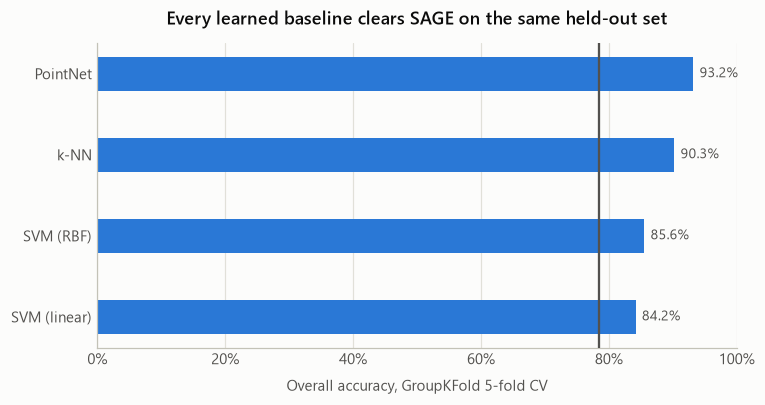

In [6]:
# Overall accuracy under GroupKFold - the regime closest to a real
# video-level split - against the SAGE reference line.
# One series -> one colour; SAGE is a reference rule, not a bar.
plot_df = (
    summary[summary["split"] == "groupkfold"]
    .assign(name=lambda d: d["model"].map(rio.pretty))
    .sort_values("overall_accuracy")
)

fig, ax = plt.subplots(figsize=(7.5, 3.6))

bars = ax.barh(
    plot_df["name"],
    plot_df["overall_accuracy"] * 100,
    height=0.42,
    color=vs.BLUE,
)

vs.label_bars(ax, bars, plot_df["overall_accuracy"] * 100, fmt="{:.1f}%")

ax.axvline(78.4, color=vs.SAGE_COLOR, linewidth=1.5, zorder=3)
ax.annotate(
    "SAGE 78.4%",
    xy=(78.4, -0.75),
    xytext=(5, 0),
    textcoords="offset points",
    va="center", ha="left", fontsize=9, color=vs.SAGE_COLOR,
)

vs.percent_axis(ax, "x")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel("Overall accuracy, GroupKFold 5-fold CV")
ax.set_title("Every learned baseline clears SAGE on the same held-out set")
plt.show()

### What the leakage was worth

All three regimes per model. The gap between the orange dot and the other
two *is* the inflation; the fact that the blue and aqua dots sit almost on
top of each other is the point of running both.

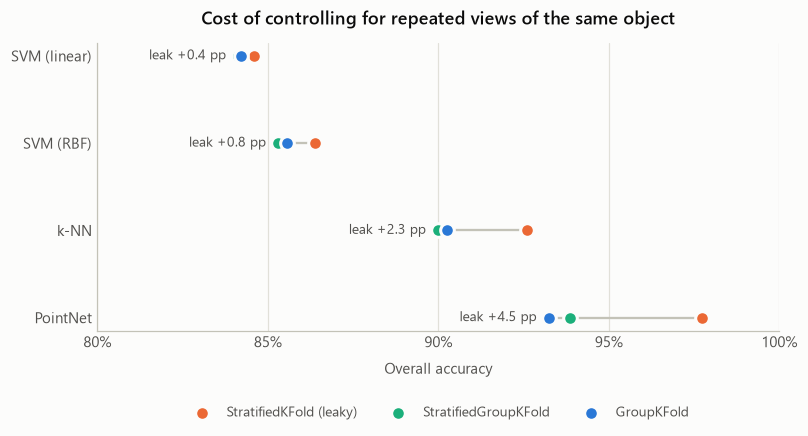

split,model,random,grouped,groupkfold,leak_pp,strat_effect_pp
0,SVM (linear),84.6,84.1,84.2,0.36,-0.09
1,SVM (RBF),86.4,85.3,85.6,0.81,-0.27
2,k-NN,92.6,90.0,90.3,2.34,-0.27
3,PointNet,97.7,93.9,93.2,4.51,0.63


In [7]:
paired = (
    summary[summary["split"] != "video_level"]
    .pivot(index="base_model", columns="split", values="overall_accuracy")
    .dropna()
)
# Leak size measured against GroupKFold, the strictest regime.
paired["leak_pp"] = (paired["random"] - paired["groupkfold"]) * 100
# Does stratifying the group folds change anything?
paired["strat_effect_pp"] = (paired["grouped"] - paired["groupkfold"]) * 100
paired = paired.sort_values("leak_pp")

fig, ax = plt.subplots(figsize=(8, 3.4))

vs.dot_plot(
    ax,
    [rio.pretty(m) for m in paired.index],
    {
        rio.SPLIT_LABELS[mode]: (paired[mode] * 100, vs.SPLIT_COLORS[mode])
        for mode in ["random", "grouped", "groupkfold"]
    },
)

for position, (_, row) in enumerate(paired.iterrows()):
    ax.annotate(
        f"leak {row['leak_pp']:+.1f} pp",
        xy=(row[["random", "grouped", "groupkfold"]].min() * 100, position),
        xytext=(-8, 0), textcoords="offset points",
        va="center", ha="right", fontsize=9, color=vs.INK_SECONDARY,
    )

vs.percent_axis(ax, "x", lo=80, top=100, step=5)
ax.set_xlabel("Overall accuracy")
ax.set_title("Cost of controlling for repeated views of the same object")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncols=3)
plt.show()

rio.as_percent(
    paired.reset_index().assign(model=lambda d: d["base_model"].map(rio.pretty)),
    columns=["random", "grouped", "groupkfold"],
)[["model", "random", "grouped", "groupkfold", "leak_pp", "strat_effect_pp"]].round(2)

Two things to read here.

**The leak.** k-NN and PointNet - the two models most able to memorise -
lose the most against `groupkfold`. The SVMs barely move. That ordering is
the signature of leakage rather than of a general difficulty change.

**Stratification barely matters.** `strat_effect_pp` - the difference
between `StratifiedGroupKFold` and plain `GroupKFold` - is a few tenths of
a point for every model, and much smaller than the leak it is being
compared against. So the conclusions do **not** depend on which group-aware
splitter you pick, which is the reassurance running both was meant to buy.

## The four findings

1. **The 13D feature set, not the scoring formula, is the ceiling on mug and
   bowl.** A linear SVM trained on the *identical* features reproduces SAGE's
   per-class failure profile (r = 0.96): mug 30.3% vs SAGE's 32.6%, bowl 20.5%
   vs 18.2%. Where SAGE fails, a learned classifier on the same numbers fails
   the same way. -> notebook 01

2. **Bottle is the exception, and it is a scoring problem.** Same inputs, but
   55.5% against SAGE's 31.5%. That one is recoverable without changing the
   representation. -> notebook 01

3. **Raw points carry far more than the 13D projection keeps.** PointNet
   reaches 93.9% overall / 92.8% balanced on the grouped split, against 64.8%
   balanced for the best feature baseline. -> notebook 02

4. **SAGE's can-vs-bottle gap is real**, not small-sample noise: +63.4 pp
   [+55.3, +71.1], Fisher exact p = 7.6e-50. -> notebook 05

## A second comparability caveat

Even with leakage controlled, the two are not measured the same way. The
baselines cross-validate *within* the validation set; SAGE's registry was built
on the training videos and evaluated zero-shot on this one. Part of the
baseline margin is that distributional advantage rather than a representational
one, so the grouped numbers are an **upper bound** on the learned classifiers,
not a clean like-for-like estimate.

The clean fix is a re-export carrying `video_id` / `frame_key` per instance.